In [2]:
import numpy as np
import pandas as pd
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier

# 1️⃣ Load dataset
df = pd.read_csv("diabetes_new2.csv")

print("Original class distribution:")
print(df['CLASS'].value_counts())

# 2️⃣ Replace 0 with NaN in numeric columns where 0 is invalid
cols_to_replace = ['Glucose','BMI','Urea','Cr','Chol','TG','HDL','LDL','VLDL']
df[cols_to_replace] = df[cols_to_replace].replace(0, np.nan)

# 3️⃣ Fill missing values with mean
for col in cols_to_replace:
    df[col] = df[col].fillna(df[col].mean())

# 4️⃣ Target variable mapping
class_mapping = {'N': 0, 'P': 1, 'Y': 2}

# Replace invalid CLASS values with the most frequent class (or choose any default)
df['CLASS_cleaned'] = df['CLASS'].map(class_mapping)
most_common_class = df['CLASS_cleaned'].mode()[0]
df['CLASS_cleaned'] = df['CLASS_cleaned'].fillna(most_common_class)

y = df['CLASS_cleaned']

print(f"\nFinal target variable info:")
print(f"NaN values in y: {y.isna().sum()}")
print("Class distribution:")
print(y.value_counts())

# 5️⃣ Features (use all columns except target and Gender)
X = df[['AGE','Urea','Cr','Glucose','Chol','TG','HDL','LDL','VLDL','BMI']]

print(f"\nFeatures used: {list(X.columns)}")
print(f"Number of features: {X.shape[1]}")

# 6️⃣ Feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 7️⃣ Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# 8️⃣ Train Decision Tree model
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

# 9️⃣ Save the trained model and scaler
joblib.dump(dt_model, "diabetes_decision_tree_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("\n✅ Decision Tree model and scaler saved successfully!")


Original class distribution:
CLASS
Y     840
N     102
P      53
Y       4
N       1
Name: count, dtype: int64

Final target variable info:
NaN values in y: 0
Class distribution:
CLASS_cleaned
2.0    845
0.0    102
1.0     53
Name: count, dtype: int64

Features used: ['AGE', 'Urea', 'Cr', 'Glucose', 'Chol', 'TG', 'HDL', 'LDL', 'VLDL', 'BMI']
Number of features: 10

✅ Decision Tree model and scaler saved successfully!


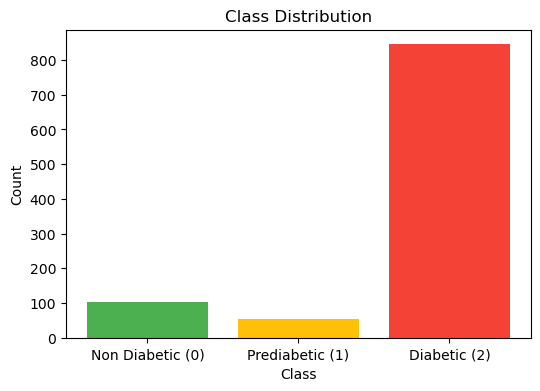

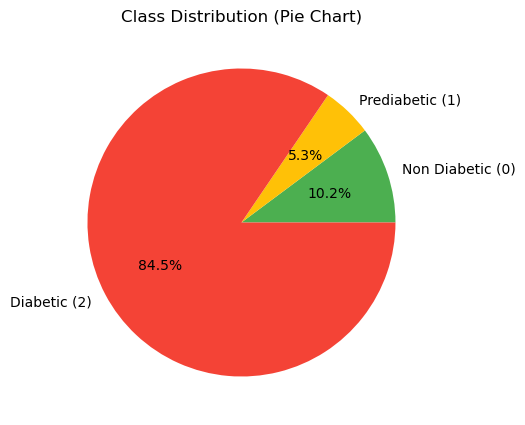

In [3]:
import matplotlib.pyplot as plt

# Class distribution
class_counts = y.value_counts().sort_index()
labels = ['Non Diabetic (0)', 'Prediabetic (1)', 'Diabetic (2)']

# --- Bar Chart ---
plt.figure(figsize=(6,4))
plt.bar(labels, class_counts, color=['#4CAF50','#FFC107','#F44336'])
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

# --- Pie Chart ---
plt.figure(figsize=(5,5))
plt.pie(class_counts, labels=labels, autopct='%1.1f%%', colors=['#4CAF50','#FFC107','#F44336'])
plt.title("Class Distribution (Pie Chart)")
plt.show()


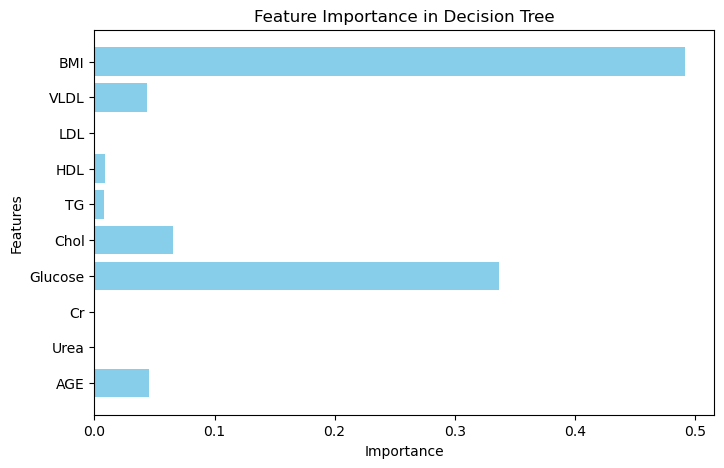

In [4]:
# Feature importance from decision tree
importances = dt_model.feature_importances_
feature_names = X.columns

plt.figure(figsize=(8,5))
plt.barh(feature_names, importances, color='skyblue')
plt.title("Feature Importance in Decision Tree")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.show()


Model Accuracy: 0.98


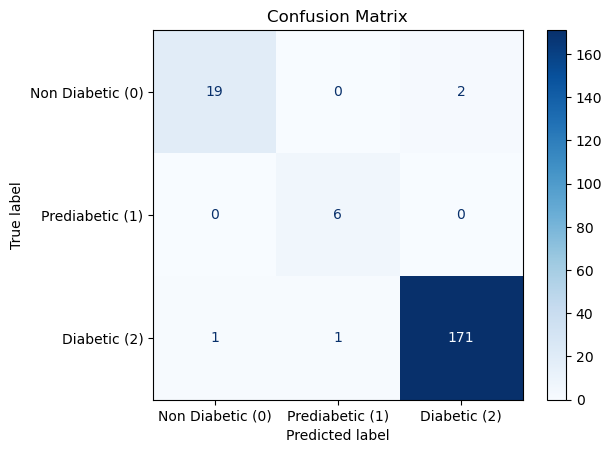

In [5]:
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# Accuracy
y_pred = dt_model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {acc:.2f}")

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()
